In [1]:
from sklearn import datasets
import numpy as np
import pickle
import pandas as pd
from sklearn.metrics import accuracy_score

In [2]:
data_breast_cancer = datasets.load_breast_cancer(as_frame=False)
X_bc = data_breast_cancer.data
y_bc = data_breast_cancer.target
print(data_breast_cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [3]:
data_iris = datasets.load_iris(as_frame=True)
X_iris = data_iris.data
y_iris = data_iris.target
print(data_iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

# Klasyfikacja

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

## Breast cancer

In [5]:
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(X_bc, y_bc, test_size = 0.2, random_state = 42)

### Bez skalowania

In [6]:
svm_clf_bc_ns = Pipeline([("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42))])

In [7]:
svm_clf_bc_ns.fit(X_bc_train[:, 3:5], y_bc_train)

/Users/maciek/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42))])

In [60]:
param_grid = {'C':[0.001, 0.01, 0.1, 1,10,100,1000]}

In [61]:
grid = GridSearchCV(LinearSVC(),param_grid,refit = True, verbose=2)

In [62]:
grid.fit(X_bc_train[:, 3:5],y_bc_train)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV] END ............................................C=0.001; total time=   0.0s
[CV] END ............................................C=0.001; total time=   0.0s
[CV] END ............................................C=0.001; total time=   0.0s
[CV] END ............................................C=0.001; total time=   0.0s
[CV] END ............................................C=0.001; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END .............................................C=0.01; total time=   0.0s
[CV] END ..............................................C=0.1; total time=   0.0s
[CV] END ........................................

GridSearchCV(estimator=LinearSVC(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}, verbose=2)

In [66]:
grid.best_params_

print(accuracy_score(y_bc_test, grid.predict(X_bc_test[:, 3:5])))

0.9298245614035088


### Ze skalowaniem

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
svm_clf_bc_s = Pipeline([("scaler", StandardScaler()),
                         ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42))])

In [10]:
svm_clf_bc_s.fit(X_bc_train[:, 3:5], y_bc_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42))])

### Accuracy

In [11]:
accuracy_list = [accuracy_score(y_bc_train, svm_clf_bc_ns.predict(X_bc_train[:, 3:5])),
                 accuracy_score(y_bc_test, svm_clf_bc_ns.predict(X_bc_test[:, 3:5])),
                 accuracy_score(y_bc_train, svm_clf_bc_s.predict(X_bc_train[:, 3:5])),
                 accuracy_score(y_bc_test, svm_clf_bc_s.predict(X_bc_test[:, 3:5]))]
                                

In [12]:
with open('bc_acc.pkl', 'wb') as f:
    pickle.dump(accuracy_list, f)

In [13]:
print(accuracy_list)

[0.6285714285714286, 0.6228070175438597, 0.8923076923076924, 0.9298245614035088]


## Iris

In [14]:
X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(pd.DataFrame(X_iris), pd.DataFrame(y_iris), test_size = 0.2, random_state = 42)

y_iris_virginica_train = (y_iris_train == 2)
y_iris_virginica_train = y_iris_virginica_train['target']

y_iris_virginica_test = (y_iris_test == 2)
y_iris_virginica_test = y_iris_virginica_test['target']

### Bez skalowania

In [15]:
svm_clf_iris_ns = Pipeline([("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42))])

In [16]:
svm_clf_iris_ns.fit(X_iris_train[['petal length (cm)', 'petal width (cm)']], y_iris_virginica_train)

/Users/maciek/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42))])

### Ze skalowaniem

In [17]:
svm_clf_iris_s = Pipeline([("scaler", StandardScaler()),
                         ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42))])

In [18]:
svm_clf_iris_s.fit(X_iris_train[['petal length (cm)', 'petal width (cm)']], y_iris_virginica_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42))])

### Accuracy

In [19]:
accuracy_list = [accuracy_score(y_iris_virginica_train, svm_clf_iris_ns.predict(X_iris_train[['petal length (cm)', 'petal width (cm)']])),
                 accuracy_score(y_iris_virginica_test, svm_clf_iris_ns.predict(X_iris_test[['petal length (cm)', 'petal width (cm)']])),
                 accuracy_score(y_iris_virginica_train, svm_clf_iris_s.predict(X_iris_train[['petal length (cm)', 'petal width (cm)']])),
                 accuracy_score(y_iris_virginica_test, svm_clf_iris_s.predict(X_iris_test[['petal length (cm)', 'petal width (cm)']]))]

In [20]:
with open('iris_acc.pkl', 'wb') as f:
    pickle.dump(accuracy_list, f)

In [21]:
print(accuracy_list)

[0.9416666666666667, 1.0, 0.9416666666666667, 1.0]


# Przyotowanie danych dla regresji

<Axes: xlabel='x', ylabel='y'>

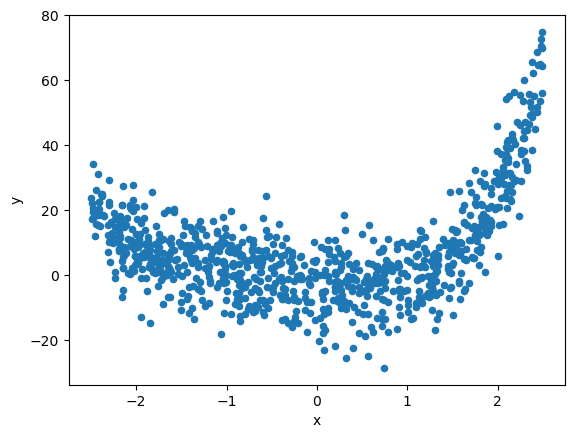

In [22]:
size = 900
X = np.random.rand(size)*5-2.5
w4, w3, w2, w1, w0 = 1, 2, 1, -4, 2
y = w4*(X**4) + w3*(X**3) + w2*(X**2) + w1*X + w0 + np.random.randn(size)*8-4
df = pd.DataFrame({'x': X, 'y': y})
df.plot.scatter(x='x',y='y')

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Regresja

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error as MSE

## LinearSVR

In [25]:
from sklearn.svm import LinearSVR

In [26]:
linear_svm_reg = Pipeline([("poly_features", PolynomialFeatures(degree=4,include_bias=False)),
                           ("scaler", StandardScaler()),
                           ("svm_reg", LinearSVR(random_state=42))])

In [27]:
linear_svm_reg.fit(X_train.reshape(-1, 1), y_train)

Pipeline(steps=[('poly_features',
                 PolynomialFeatures(degree=4, include_bias=False)),
                ('scaler', StandardScaler()),
                ('svm_reg', LinearSVR(random_state=42))])

In [28]:
MSE_linear_train = MSE(y_train, linear_svm_reg.predict(X_train.reshape(-1,1)))
MSE_linear_test = MSE(y_test, linear_svm_reg.predict(X_test.reshape(-1,1)))

In [29]:
print(MSE_linear_test)

72.75830985646066


In [30]:
print(MSE_linear_train)

62.50029872505366


## SVR

In [31]:
from sklearn.svm import SVR

### Domyślnie

In [32]:
svm_reg_default = Pipeline([("scaler", StandardScaler()),
                           ("svm_reg", SVR(kernel="poly", degree=4))])

In [33]:
svm_reg_default.fit(X_train.reshape(-1, 1), y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_reg', SVR(degree=4, kernel='poly'))])

In [34]:
MSE_svm_default_train = MSE(y_train, svm_reg_default.predict(X_train.reshape(-1,1)))
MSE_svm_default_test = MSE(y_test, svm_reg_default.predict(X_test.reshape(-1,1)))

In [35]:
print(MSE_svm_default_train)

101.30894393821004


In [36]:
print(MSE_svm_default_test)

117.79704438126412


### GridSearchCV

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
param_grid = {"svm_reg__C" : [0.1, 1, 10], "svm_reg__coef0": [0.1, 1, 10]}

In [39]:
search = GridSearchCV(svm_reg_default, param_grid, scoring='neg_mean_squared_error', n_jobs=-1)

In [40]:
search.fit(X.reshape(-1, 1), y)

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm_reg',
                                        SVR(degree=4, kernel='poly'))]),
             n_jobs=-1,
             param_grid={'svm_reg__C': [0.1, 1, 10],
                         'svm_reg__coef0': [0.1, 1, 10]},
             scoring='neg_mean_squared_error')

In [41]:
print(f"Cross-validated score = {search.best_score_}")
print(search.best_params_)

Cross-validated score = -63.80654327611843
{'svm_reg__C': 10, 'svm_reg__coef0': 10}


#### SVR raz jeszcze

In [42]:
svm_reg = Pipeline([("scaler", StandardScaler()),
                    ("svm_reg", SVR(kernel="poly", degree=4,
                                    C=search.best_params_['svm_reg__C'],
                                    coef0=search.best_params_['svm_reg__coef0']))])

In [43]:
svm_reg.fit(X_train.reshape(-1, 1), y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_reg', SVR(C=10, coef0=10, degree=4, kernel='poly'))])

In [44]:
MSE_svm_train = MSE(y_train, svm_reg.predict(X_train.reshape(-1,1)))
MSE_svm_test = MSE(y_test, svm_reg.predict(X_test.reshape(-1,1)))

In [45]:
print(MSE_svm_train)

62.05297930278522


In [46]:
print(MSE_svm_test)

70.14350517637088


## Zapisanie MSE

In [47]:
MSE_list = [MSE_linear_train, MSE_linear_test, MSE_svm_train, MSE_svm_test]

In [48]:
with open('reg_mse.pkl', 'wb') as f:
    pickle.dump(MSE_list, f)

In [49]:
print(MSE_list)

[62.50029872505366, 72.75830985646066, 62.05297930278522, 70.14350517637088]


In [50]:
X_train.shape

(720,)

In [51]:
X_test.shape

(180,)

In [52]:
y_train.shape

(720,)

In [53]:
y_test.shape

(180,)